In [14]:
import pandas as pd
import numpy as np
import pickle

from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

from statsmodels.tsa.arima.model import ARIMA
import warnings

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.api import VAR
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

import matplotlib.cm as cm

In [15]:
warnings.filterwarnings("ignore")

In [16]:
df = pd.read_csv("../../data/data.csv")

In [17]:
df.head()

,Tên_mặt_hàng,Thị_trường,Loại_giá,Đơn_vị_tính,Loại_tiền,Nguồn,Ngày,Giá,Ngành_hàng
0,Cà phê Robusta nhân xô,Đắk Lắk,Thương lái thu mua,Vnđ/Kg,VNĐ,CTV địa phương,5/9/2025 12:00:00 AM,128233.0,Cà phê
1,Cà phê Robusta nhân xô,Đắk Nông,Thương lái thu mua,Vnđ/Kg,VNĐ,CTV địa phương,5/9/2025 12:00:00 AM,128350.0,Cà phê
2,Cà phê Robusta nhân xô,Gia Lai,Thương lái thu mua,Vnđ/Kg,VNĐ,CTV địa phương,5/9/2025 12:00:00 AM,128233.0,Cà phê
3,Cà phê Robusta nhân xô,Kon Tum,Thương lái thu mua,Vnđ/Kg,VNĐ,CTV địa phương,5/9/2025 12:00:00 AM,128200.0,Cà phê
4,Cà phê Robusta nhân xô,Lâm Đồng,Thương lái thu mua,Vnđ/Kg,VNĐ,CTV địa phương,5/9/2025 12:00:00 AM,128000.0,Cà phê


In [18]:
df["Ngày"] = pd.to_datetime(df["Ngày"], format="%m/%d/%Y %I:%M:%S %p")

In [19]:
del df["Loại_tiền"]
del df["Đơn_vị_tính"]

In [20]:
cmap = cm.get_cmap('Set3', 12)
color_list = [cmap(i) for i in range(cmap.N)]

# Trực quan dữ liệu thô

## Tất cả các ngành

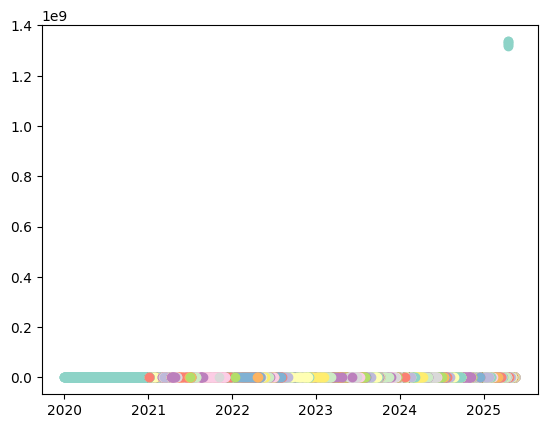

In [26]:
for idx, item in enumerate(df["Tên_mặt_hàng"].unique()):
    item_df = df[df["Tên_mặt_hàng"] == item].sort_values("Ngày")

    date = item_df["Ngày"]
    price = item_df["Giá"]

    plt.scatter(date, price, color=color_list[idx%12])

## Ngành cà phê

In [22]:
caphe_df = df[df["Ngành_hàng"] == "Cà phê"]
caphe_df.head()

,Tên_mặt_hàng,Thị_trường,Loại_giá,Nguồn,Ngày,Giá,Ngành_hàng
0,Cà phê Robusta nhân xô,Đắk Lắk,Thương lái thu mua,CTV địa phương,2025-05-09,128233.0,Cà phê
1,Cà phê Robusta nhân xô,Đắk Nông,Thương lái thu mua,CTV địa phương,2025-05-09,128350.0,Cà phê
2,Cà phê Robusta nhân xô,Gia Lai,Thương lái thu mua,CTV địa phương,2025-05-09,128233.0,Cà phê
3,Cà phê Robusta nhân xô,Kon Tum,Thương lái thu mua,CTV địa phương,2025-05-09,128200.0,Cà phê
4,Cà phê Robusta nhân xô,Lâm Đồng,Thương lái thu mua,CTV địa phương,2025-05-09,128000.0,Cà phê


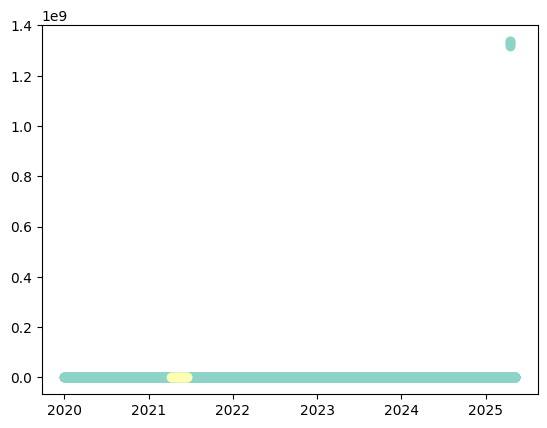

In [24]:
for idx, item in enumerate(caphe_df["Tên_mặt_hàng"].unique()):
    item_df = caphe_df[caphe_df["Tên_mặt_hàng"] == item].sort_values("Ngày")

    date = item_df["Ngày"]
    price = item_df["Giá"]

    plt.scatter(date, price, color=color_list[idx])

## Ngành rau quả

In [28]:
rauqua_df = df[df["Ngành_hàng"] == "Rau, quả"]
rauqua_df.head()

,Tên_mặt_hàng,Thị_trường,Loại_giá,Nguồn,Ngày,Giá,Ngành_hàng
21895,Bắp cải,Sơn La,Bán lẻ,CTV địa phương,2025-05-19,10000.0,"Rau, quả"
21896,Bắp cải thảo,Sơn La,Bán lẻ,CTV địa phương,2025-05-19,10000.0,"Rau, quả"
21897,Bưởi da xanh,Sơn La,Bán lẻ,CTV địa phương,2025-05-19,35000.0,"Rau, quả"
21898,Bưởi Diễn,Sơn La,Bán lẻ,CTV địa phương,2025-05-19,10000.0,"Rau, quả"
21899,Cà chua,Sơn La,Bán lẻ,CTV địa phương,2025-05-19,12000.0,"Rau, quả"


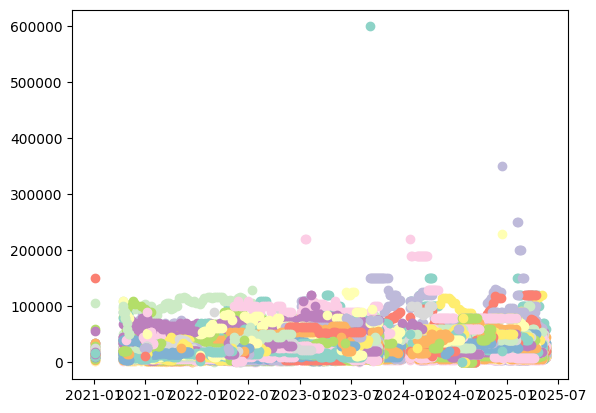

In [30]:
for idx, item in enumerate(rauqua_df["Tên_mặt_hàng"].unique()):
    item_df = rauqua_df[rauqua_df["Tên_mặt_hàng"] == item].sort_values("Ngày")

    date = item_df["Ngày"]
    price = item_df["Giá"]

    plt.scatter(date, price, color=color_list[idx%12])

## Ngành lúa gạo

In [32]:
lugao_df = df[df["Ngành_hàng"] == "Lúa, gạo"]
lugao_df.head()

,Tên_mặt_hàng,Thị_trường,Loại_giá,Nguồn,Ngày,Giá,Ngành_hàng
4845,CLC 4900,Cần Thơ,Thương lái thu mua,CTV địa phương,2025-05-19,16000.00,"Lúa, gạo"
4846,IR 5451,Cần Thơ,Thương lái thu mua,CTV địa phương,2025-05-19,7000.00,"Lúa, gạo"
4847,Jasmine,Cần Thơ,Thương lái thu mua,CTV địa phương,2025-05-19,11266.67,"Lúa, gạo"
4848,OM 18,Cần Thơ,Thương lái thu mua,CTV địa phương,2025-05-19,7000.00,"Lúa, gạo"
4849,OM 5451,Cần Thơ,Thương lái thu mua,CTV địa phương,2025-05-19,6000.00,"Lúa, gạo"


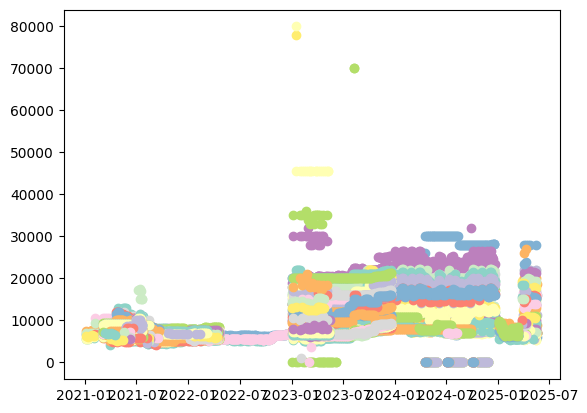

In [33]:
for idx, item in enumerate(lugao_df["Tên_mặt_hàng"].unique()):
    item_df = lugao_df[lugao_df["Tên_mặt_hàng"] == item].sort_values("Ngày")

    date = item_df["Ngày"]
    price = item_df["Giá"]

    plt.scatter(date, price, color=color_list[idx%12])

In [ ]:
del df["Ngành_hàng"]

# Kiểm tra dữ liệu thiếu

In [ ]:
df.isnull().sum()

Tên_mặt_hàng    0
Thị_trường      0
Loại_giá        0
Nguồn           0
Ngày            0
Giá             0
dtype: int64

# Kiểm tra dữ liệu thừa

In [ ]:
df.duplicated().sum()

np.int64(3)

In [ ]:
df.drop_duplicates()

,Tên_mặt_hàng,Thị_trường,Loại_giá,Nguồn,Ngày,Giá
0,Cà phê Robusta nhân xô,Đắk Lắk,Thương lái thu mua,CTV địa phương,2025-05-09,128233.0
1,Cà phê Robusta nhân xô,Đắk Nông,Thương lái thu mua,CTV địa phương,2025-05-09,128350.0
2,Cà phê Robusta nhân xô,Gia Lai,Thương lái thu mua,CTV địa phương,2025-05-09,128233.0
3,Cà phê Robusta nhân xô,Kon Tum,Thương lái thu mua,CTV địa phương,2025-05-09,128200.0
4,Cà phê Robusta nhân xô,Lâm Đồng,Thương lái thu mua,CTV địa phương,2025-05-09,128000.0
...,...,...,...,...,...,...
51483,Quýt ngọt Phù Yên,Sơn La,Bán lẻ,CTV địa phương,2021-01-04,35000.0
51484,Rau cải,Sơn La,Bán lẻ,CTV địa phương,2021-01-04,12000.0
51485,Su hào,Sơn La,Bán lẻ,CTV địa phương,2021-01-04,10000.0
51486,Su su quả,Sơn La,Bán lẻ,CTV địa phương,2021-01-04,12000.0


In [ ]:
len(df)

51488